# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)


In [5]:
# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

In [6]:
# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [8]:
df [:5]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [9]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

In [10]:
df [:5]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,month_year
datetime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0,2011-01
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1,2011-01
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2,2011-01
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3,2011-01
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4,2011-01


In [12]:
m_y_avg = df.groupby (['month_year']) ['count'].mean ()
m_y_avg

month_year
2011-01     54.645012
2011-02     73.641256
2011-03     86.849776
2011-04    111.026374
2011-05    174.809211
2011-06    196.877193
2011-07    203.614035
2011-08    182.666667
2011-09    174.622517
2011-10    174.773626
2011-11    155.458333
2011-12    134.173246
2012-01    124.353201
2012-02    145.646154
2012-03    208.276923
2012-04    257.455947
2012-05    264.109649
2012-06    287.186404
2012-07    267.037281
2012-08    285.570175
2012-09    292.598684
2012-10    280.508772
2012-11    231.980220
2012-12    217.054825
Name: count, dtype: float64

In [14]:
m_y_pivot = pd.pivot_table(
    df,
    values='count',     
    index='month_year',        
    aggfunc='mean'     
)
m_y_pivot

,count
month_year,
2011-01,54.645012
2011-02,73.641256
2011-03,86.849776
2011-04,111.026374
2011-05,174.809211
2011-06,196.877193
2011-07,203.614035
2011-08,182.666667
2011-09,174.622517


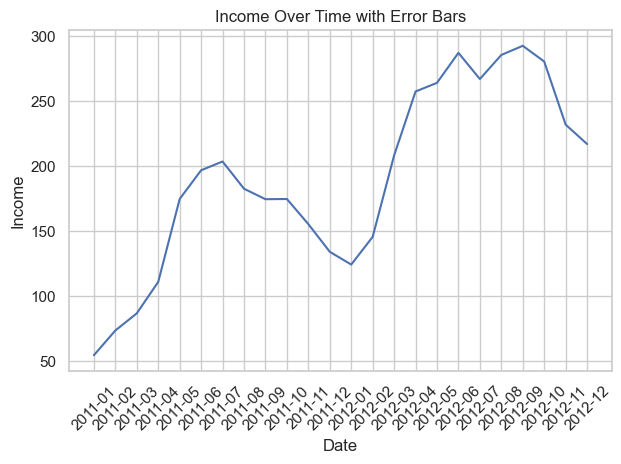

In [15]:
sns.lineplot(m_y_pivot, x='month_year', y='count', errorbar='sd')
plt.title('Income Over Time with Error Bars')
plt.xlabel('Date')
plt.ylabel('Income')
plt.xticks(rotation=45)
plt.tight_layout();

В такому випадку не буде стандартного відхилення. адже дані загреговані вже. Тоді зробимо інакше. Перетворимо стрінгу в datetime, або можна використовувати стрінгу як категорії. Краще datetime

In [16]:
df['month_year'] = pd.to_datetime(df['month_year'])

In [18]:
df = df.sort_values('month_year')
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,month_year
datetime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0,2011-01-01
2011-01-01 23:00:00,1,0,0,2,18.86,22.725,88,19.9995,15,24,39,2011-01-01,1,52,5,Saturday,2011,1,23,2011-01-01
2011-01-10 06:00:00,1,0,1,1,4.92,6.060,50,19.0012,0,31,31,2011-01-10,10,2,0,Monday,2011,1,6,2011-01-01
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1,2011-01-01
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2,2011-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 18:00:00,4,0,1,1,15.58,19.695,50,23.9994,23,546,569,2012-12-19,19,51,2,Wednesday,2012,12,18,2012-12-01
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19,2012-12-01
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20,2012-12-01


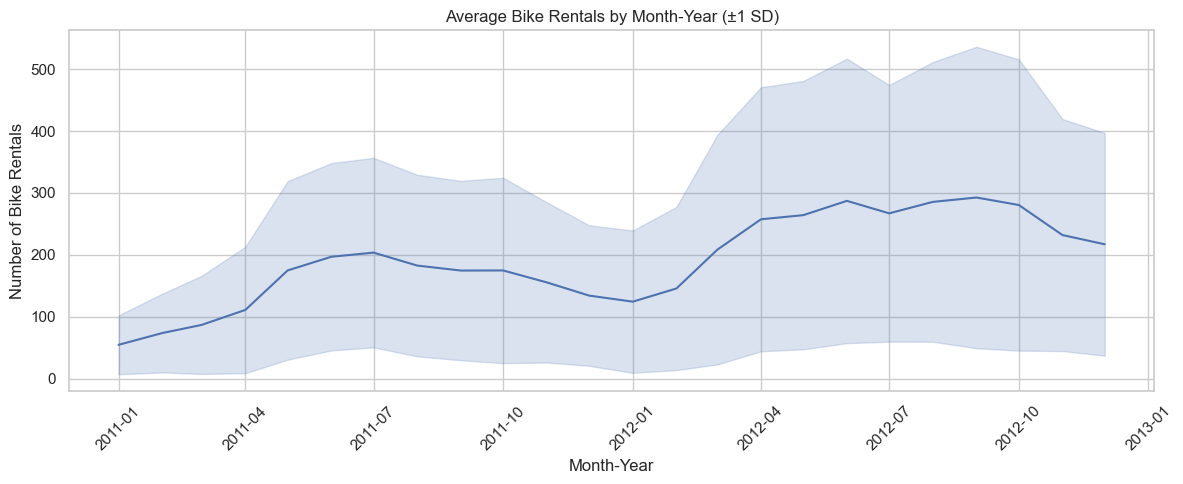

In [20]:
plt.figure(figsize=(12, 5))

sns.lineplot (
    df, 
    x = 'month_year', 
    y = 'count',
    estimator='mean',   # середнє по місяцю
    errorbar='sd' 
)
plt.title('Average Bike Rentals by Month-Year (±1 SD)')
plt.xlabel('Month-Year')
plt.ylabel('Number of Bike Rentals')
plt.xticks (rotation = 45)
plt.tight_layout()
plt.show()

графік є але немає тіків на кожен мфсяць щоб дати відповідь на аналітичне питання. тому спробуємо через subplots і додамо xticks на кожен місяць

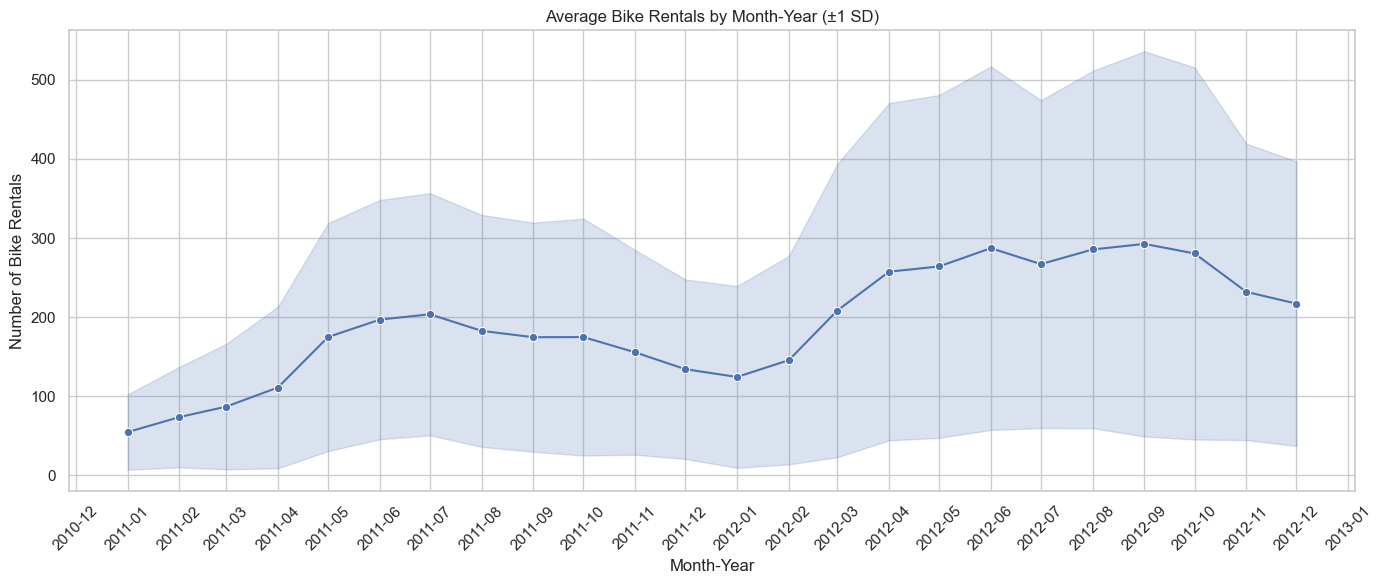

In [24]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=df,
    x='month_year',
    y='count',
    errorbar='sd',
    marker='o',
    ax=ax
)

# тіки кожного місяця
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.title('Average Bike Rentals by Month-Year (±1 SD)')
plt.xlabel('Month-Year')
plt.ylabel('Number of Bike Rentals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Тепер на графіку видно окремо по місяцях більш чітко інформацію. З квітня 2012 до жовтня 2012  найбільший довірчий інтервад і найбільша невизначеність даних. Найбільша невизначеність часто буває: коли погода нестабільна, попит сильно змінюється


## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

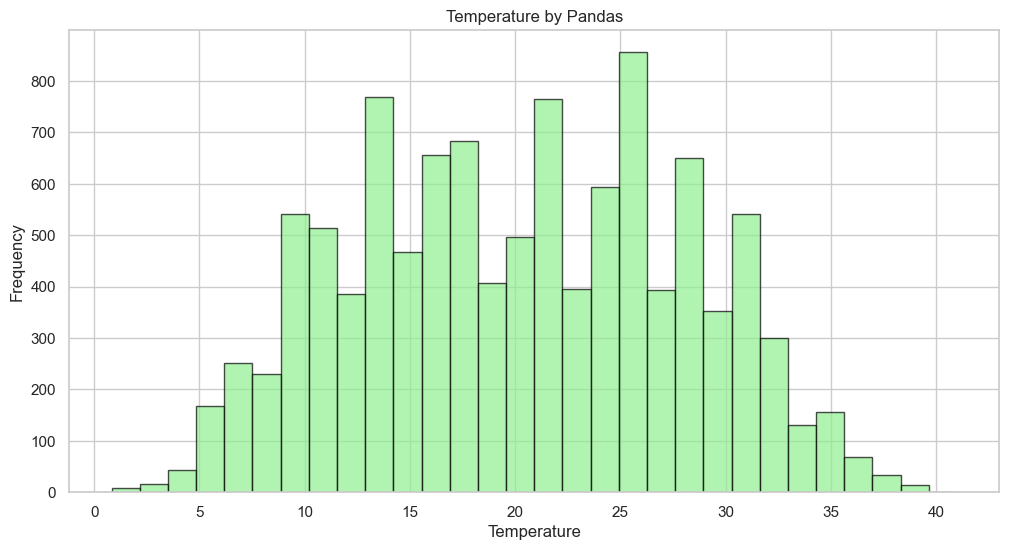

In [34]:
df ['temp'].plot.hist (
    figsize = (12, 6),
    bins = 30,
    color = 'lightgreen',
    edgecolor = 'black',
    alpha = 0.7
)
plt. title ('Temperature Distribution by Pandas')
plt.xlabel('Temperature')
plt.ylabel('Frequency');

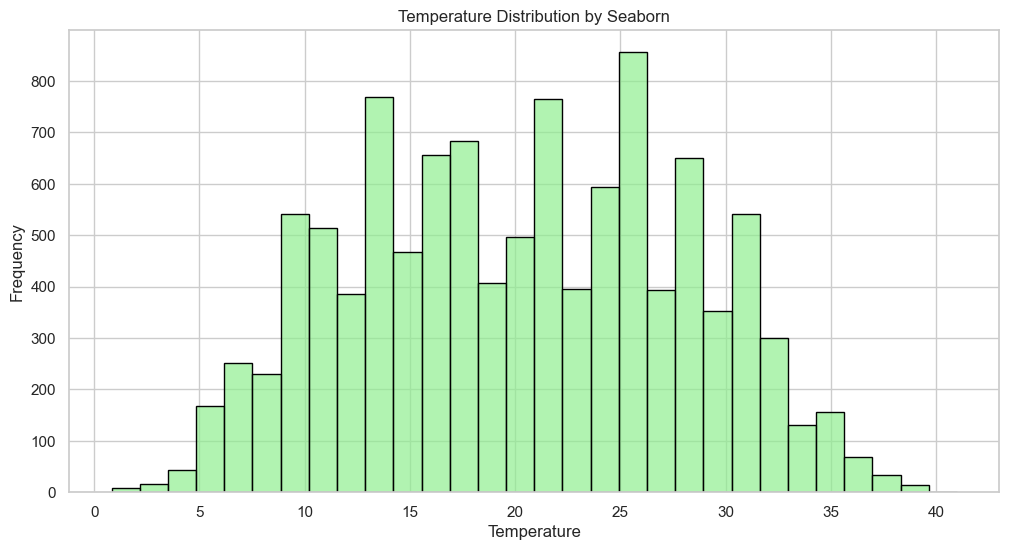

In [38]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='temp',
    bins=30,
    color='lightgreen',
    edgecolor='black',
    alpha=0.7,
    kde=True
)

plt.title('Temperature Distribution by Seaborn')
plt.xlabel('Temperature')
plt.ylabel('Frequency');

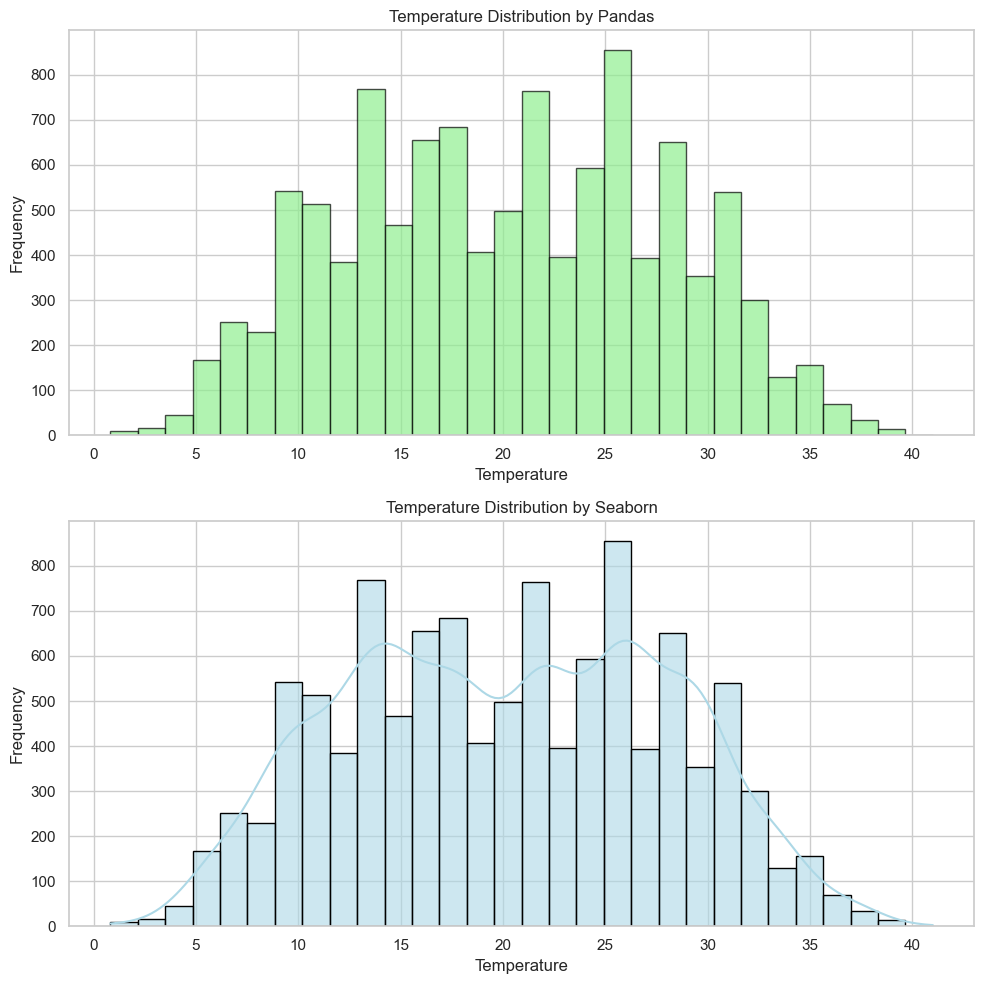

In [39]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))  

#  1. Pandas гістограма
df['temp'].plot.hist(
    bins=30,
    color='lightgreen',
    edgecolor='black',
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title('Temperature Distribution by Pandas')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Frequency')

# 2. Seaborn гістограма
sns.histplot(
    data=df,
    x='temp',
    bins=30,
    kde=True,
    color='lightblue',
    edgecolor='black',
    alpha=0.6,
    ax=axes[1]
)

axes[1].set_title('Temperature Distribution by Seaborn')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show() 

З урахуванням дуже базових вимог до цих конкретних графіків візуальної різниці між графіками не видно. хоча теоретично seaborn є бульш функціоевльним і має різні доповнення. Основна різниця в кривій KDE — Kernel Density Estimate / оцінка щільності розподілу. Це плавна лінія, яка показує, де значення концентруються найбільше, і допомагає побачити загальну форму розподілу без впливу кількості інтервалів.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [43]:
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

df['weather_label'] = df['weather'].map(weather_labels)
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,...,date,day,week,weekday_num,weekday,year,month,hour,month_year,weather_label
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,...,2011-01-01,1,52,5,Saturday,2011,1,0,2011-01-01,Ясно
2011-01-01 23:00:00,1,0,0,2,18.86,22.725,88,19.9995,15,24,...,2011-01-01,1,52,5,Saturday,2011,1,23,2011-01-01,Туман
2011-01-10 06:00:00,1,0,1,1,4.92,6.060,50,19.0012,0,31,...,2011-01-10,10,2,0,Monday,2011,1,6,2011-01-01,Ясно
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,...,2011-01-01,1,52,5,Saturday,2011,1,1,2011-01-01,Ясно
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,...,2011-01-01,1,52,5,Saturday,2011,1,2,2011-01-01,Ясно
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 18:00:00,4,0,1,1,15.58,19.695,50,23.9994,23,546,...,2012-12-19,19,51,2,Wednesday,2012,12,18,2012-12-01,Ясно
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,...,2012-12-19,19,51,2,Wednesday,2012,12,19,2012-12-01,Ясно
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,...,2012-12-19,19,51,2,Wednesday,2012,12,20,2012-12-01,Ясно


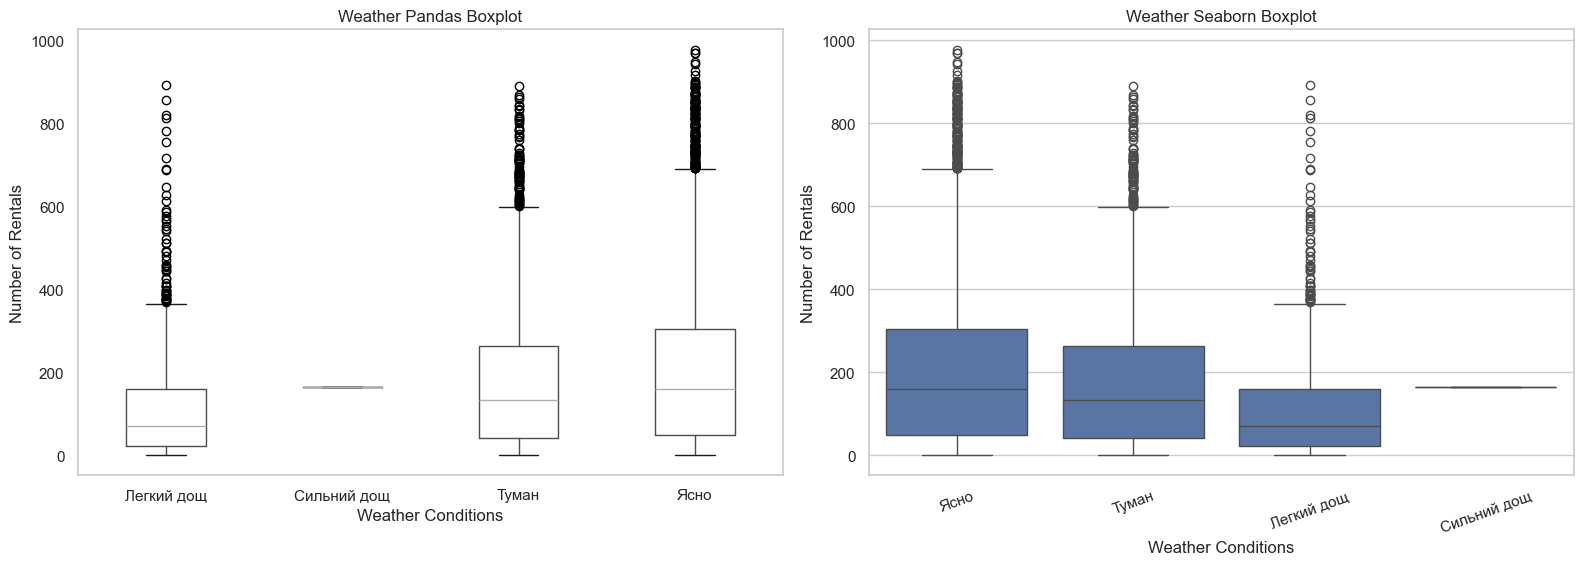

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pandas
df.boxplot(
    column='count',
    by='weather_label',
    grid=False,
    ax=axes[0]
)

axes[0].set_title('Weather Pandas Boxplot')
axes[0].set_xlabel('Weather Conditions')
axes[0].set_ylabel('Number of Rentals')

plt.suptitle('')

# Seaborn
sns.boxplot(
    data=df,
    x='weather_label',
    y='count',
    ax=axes[1]
)

axes[1].set_title('Weather Seaborn Boxplot')
axes[1].set_xlabel('Weather Conditions')
axes[1].set_ylabel('Number of Rentals')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

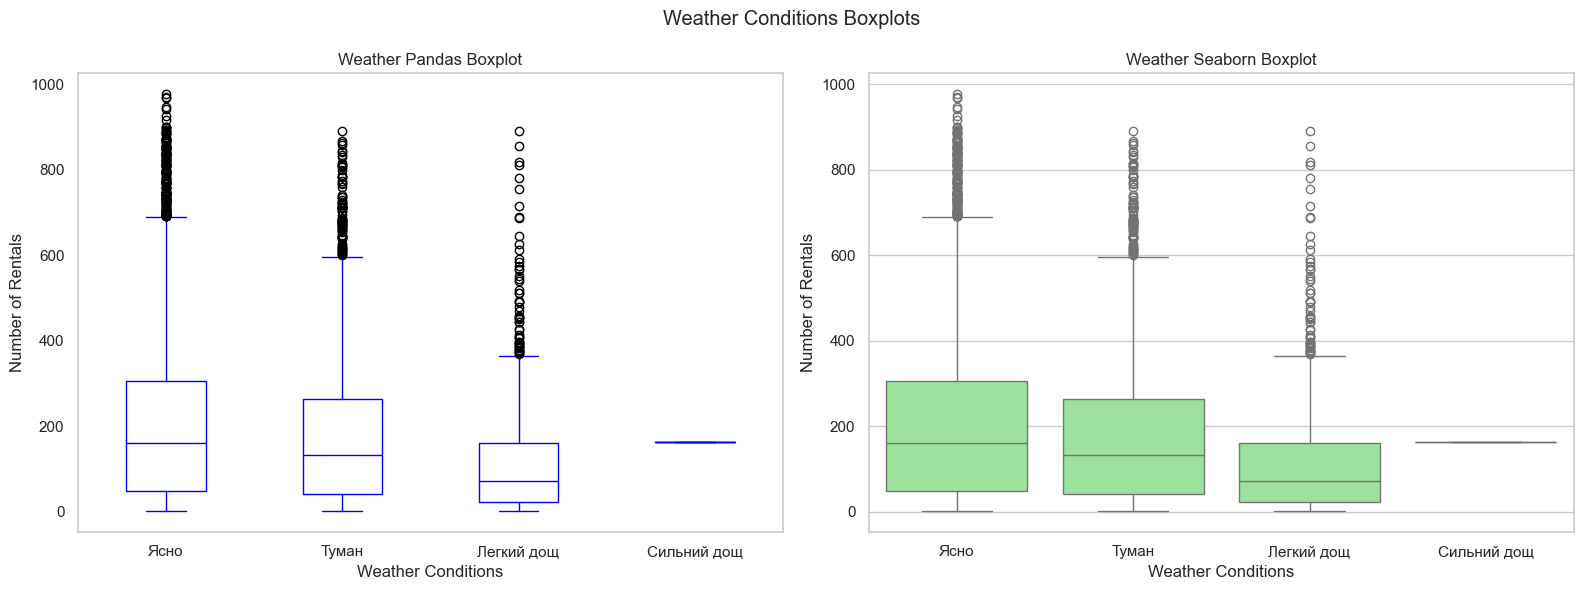

In [51]:
order = [
    'Ясно',
    'Туман',
    'Легкий дощ',
    'Сильний дощ'
]

df['weather_label'] = pd.Categorical(
    df['weather_label'],
    categories=order,
    ordered=True
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pandas
df.boxplot(
    column='count',
    by='weather_label',
    grid=False,
    color = 'blue',
    ax=axes[0]
)

axes[0].set_title('Weather Pandas Boxplot')
axes[0].set_xlabel('Weather Conditions')
axes[0].set_ylabel('Number of Rentals')


# Seaborn
sns.boxplot(
    data=df,
    x='weather_label',
    y='count',
    color = 'lightgreen',
    ax=axes[1]
)

axes[1].set_title('Weather Seaborn Boxplot')
axes[1].set_xlabel('Weather Conditions')
axes[1].set_ylabel('Number of Rentals')

plt.suptitle('Weather Conditions Boxplots')
plt.tight_layout()
plt.show()

Візуальна різниця між двома графіками полігає в аступних аспектах: 
1. В Seaborn автоматично додається сітка grid
2. По-різному розташовані бокси за погодніми умовами. Pandas розташував в алфавітному порядку. Seaborn - в порядку появию Щоб зробити однакоов потрібно було задати order, categorical.
3. При задаванні параметру color Seaborn заливає . замальовує відповідним кольором бокс (або можна вибрати палітру через palete), тоді як Pandas малює саме межі бокса відповідним кольором

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [52]:
df.dtypes

season                    int64
holiday                   int64
workingday                int64
weather                   int64
temp                    float64
atemp                   float64
humidity                  int64
windspeed               float64
casual                    int64
registered                int64
count                     int64
date                     object
day                       int32
week                     UInt32
weekday_num               int32
weekday                     str
year                      int32
month                     int32
hour                      int32
month_year       datetime64[us]
weather_label          category
dtype: object

In [58]:
correlation = df [['temp', 'atemp', 'humidity', 'windspeed', 'registered', 'casual', 'count']].corr()
correlation

,temp,atemp,humidity,windspeed,registered,casual,count
temp,1.000000,0.984948,-0.064949,-0.017852,0.318571,0.467097,0.394454
atemp,0.984948,1.000000,-0.043536,-0.057473,0.314635,0.462067,0.389784
humidity,-0.064949,-0.043536,1.000000,-0.318607,-0.265458,-0.348187,-0.317371
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.091052,0.092276,0.101369
registered,0.318571,0.314635,-0.265458,0.091052,1.000000,0.497250,0.970948
casual,0.467097,0.462067,-0.348187,0.092276,0.497250,1.000000,0.690414
count,0.394454,0.389784,-0.317371,0.101369,0.970948,0.690414,1.000000


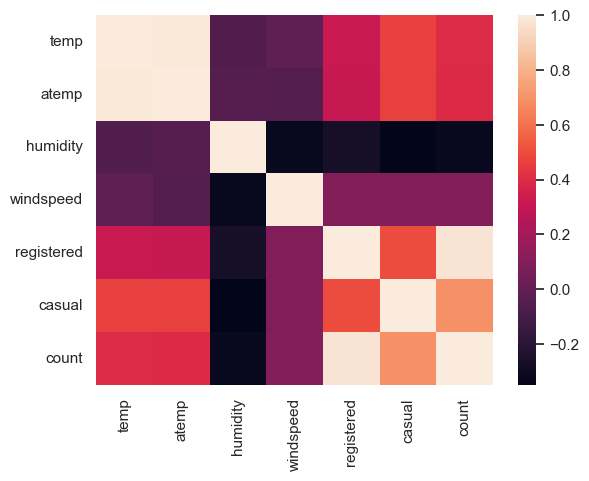

In [59]:
sns.heatmap(correlation);

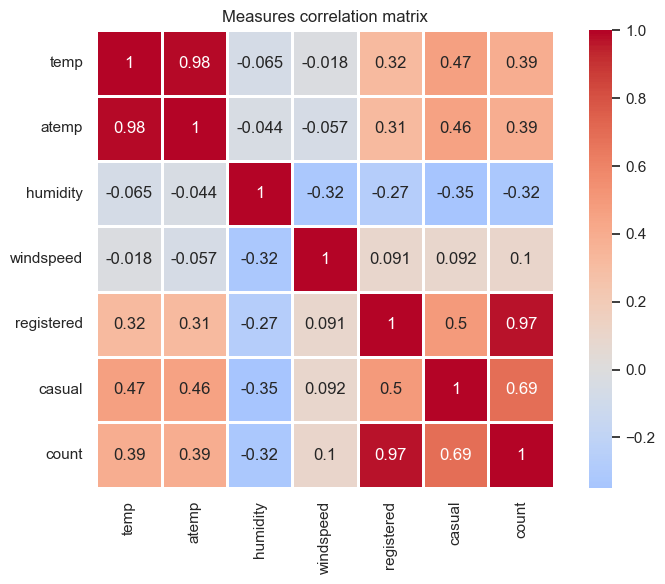

In [60]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1
            )

plt.title('Measures correlation matrix')
plt.tight_layout()
plt.show()

1. Які змінні найсильніше корелюють з загальною кількістю оренди (count). на графіку можна побачити найбільшу кореляцію з regestered / casual. Але цей момент потрібно пояснити, адже висока кореляція між цими змінними є наслідком їхньої формульної залежності , оскільки count = registered + casual, а не окремого статистичного ефекту. Серед іншого набільша кореляція з температурою і її відчуттям.
2. Яка кореляція між temp та atemp? Між temp та atemp спостерігається дуже сильна позитивна кореляція (близько 0.99), що свідчить про майже повну лінійну залежність між фактичною та відчутною температурою
3. Які змінні мають негативну кореляцію? Негативна кореляція спостерігається між humidity та змінними, що відображають кількість оренд (count, casual, registered). Це означає, що зі зростанням вологості попит на велосипеди зменшується.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


C:\Users\vkozy\AppData\Local\Temp\ipykernel_24436\242978478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


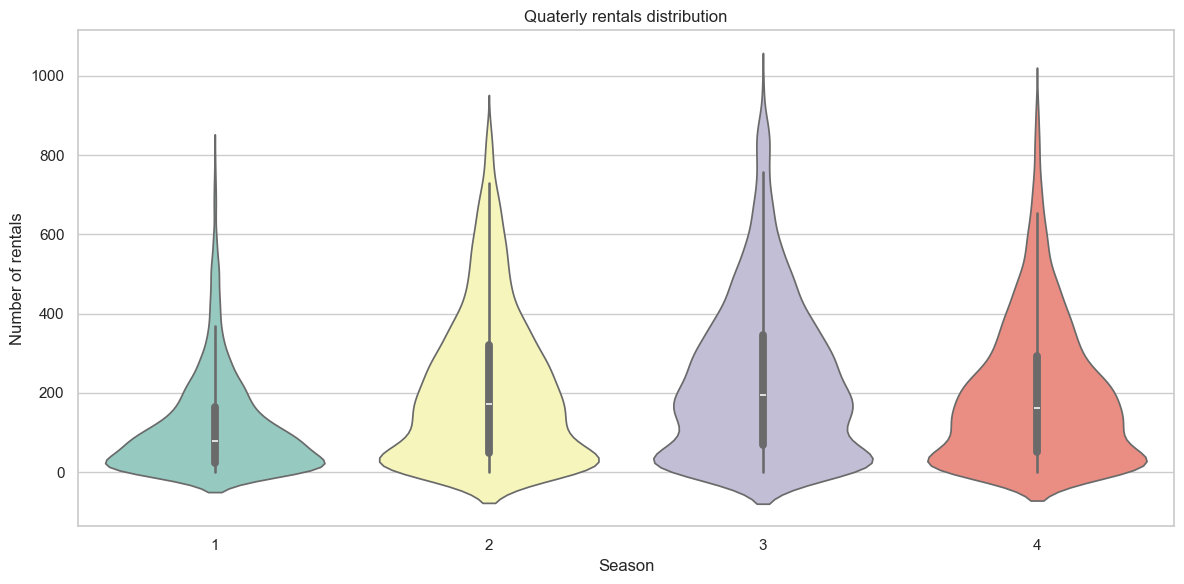

In [65]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df, 
    x='season', 
    y='count',
    palette='Set3'
 )

plt.xlabel ('Season')
plt.ylabel ('Number of rentals')
plt.title('Quaterly rentals distribution')
plt.tight_layout()
plt.show()

1. Чим ширша “скрипка” в певній точці по осі Y — тим більше значень там зосереджено.
2. Найбільша варіабельність оренди протягом 3 сезона. адже має біший розкид даних судячи з довжини хвоста
3. Перевага violin plot полягає в тому, що він показує форму розподілу даних, тоді як box plot відображає лише основні статистичні показники.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

In [66]:
df.shape

(10886, 21)

In [70]:
df.sample(frac=0.1).shape

(1089, 21)

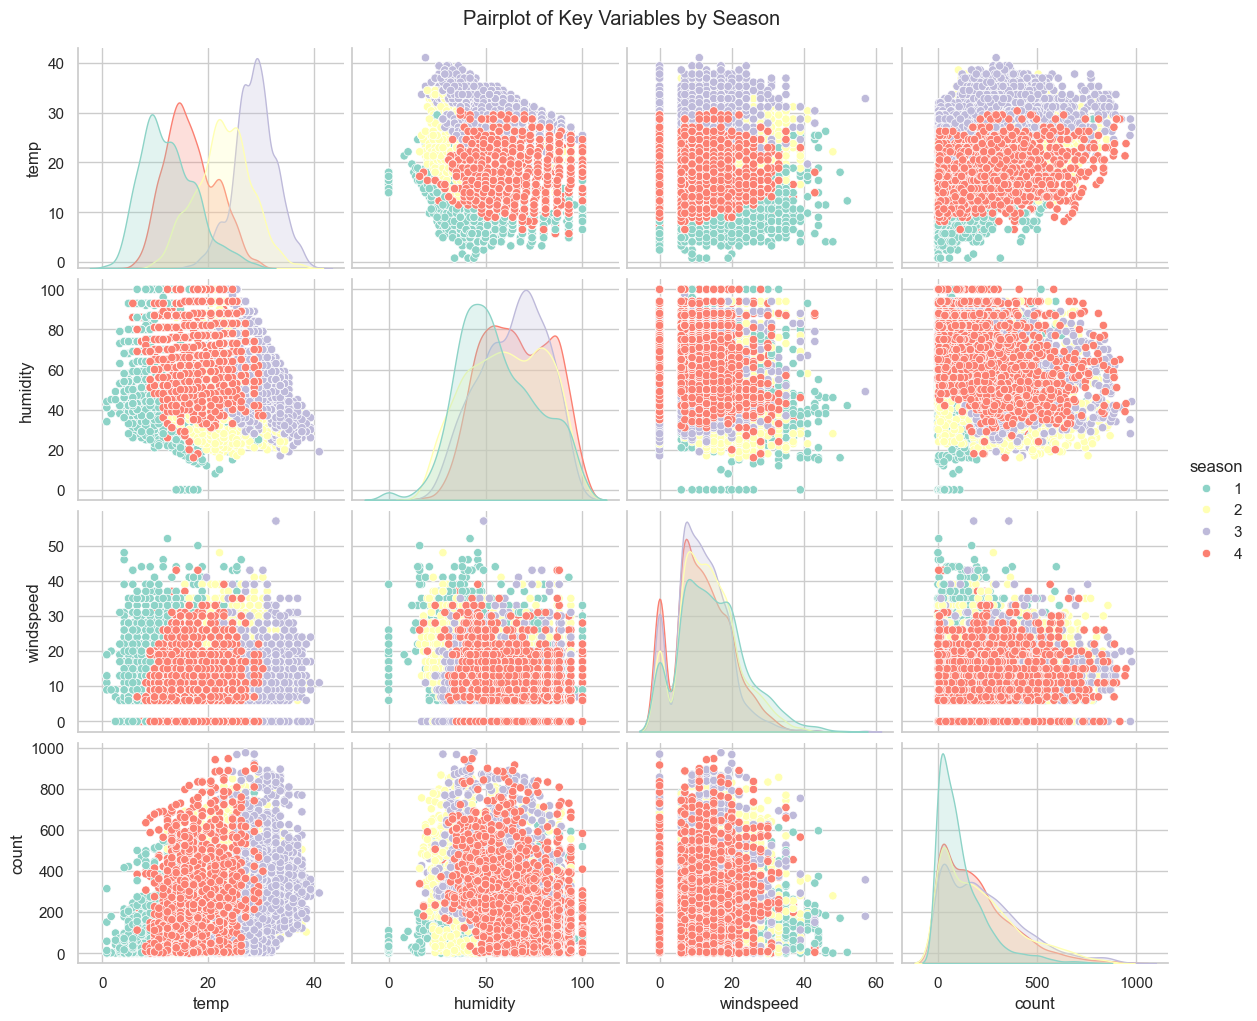

In [73]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count', 'season']]

sns.pairplot(sample_df,
             hue='season', 
             height=2.5, 
             aspect=1.2,
             palette='Set3'
)
plt.suptitle('Pairplot of Key Variables by Season', y=1.02)
plt.show()

1. Найсильніший лінійний зв'язок між count і temp
2. Найбільше між кварталами відрізняється температруа і кількість оренд.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

In [75]:
# створюємо колонку з типом дня робочий - вихідний
df['workingday_label'] = df['workingday'].map({
    0: 'Weekend',
    1: 'Working day'
})
df [:5]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,...,week,weekday_num,weekday,year,month,hour,month_year,weather_label,day_type,workingday_label
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,...,52,5,Saturday,2011,1,0,2011-01-01,Ясно,Weekend,Weekend
2011-01-01 23:00:00,1,0,0,2,18.86,22.725,88,19.9995,15,24,...,52,5,Saturday,2011,1,23,2011-01-01,Туман,Weekend,Weekend
2011-01-10 06:00:00,1,0,1,1,4.92,6.060,50,19.0012,0,31,...,2,0,Monday,2011,1,6,2011-01-01,Ясно,Working day,Working day
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,...,52,5,Saturday,2011,1,1,2011-01-01,Ясно,Weekend,Weekend
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,...,52,5,Saturday,2011,1,2,2011-01-01,Ясно,Weekend,Weekend


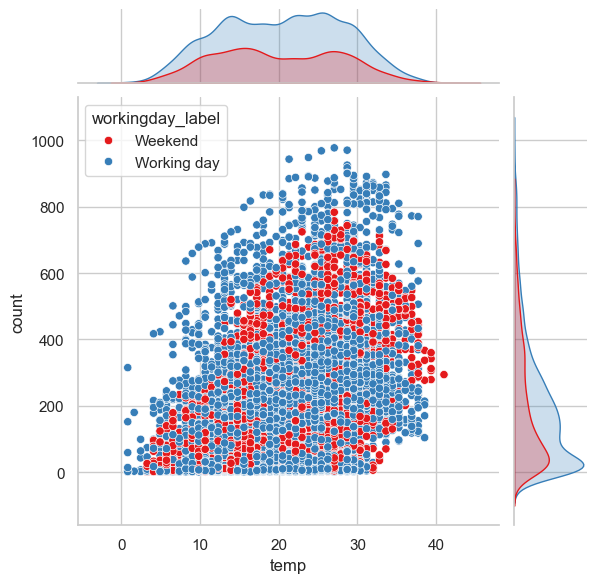

In [79]:
sns.jointplot(
    data=df,
    x='temp',
    y='count',
    hue='workingday_label',
    height=6,
    palette='Set1'
)

plt.show()

1. Графіки по краях показують розподіл даних.
   Верхній графік (temp): Розподіли дуже схожі → температура не сильно відрізняється між working і weekend
   Правий графік (count): Синя крива: довший "хвіст", більше високих значень. Тобто у робочі дні більше пікових значень оренд.
2. В розрізі порівняння показників кількості оренд і температурних показників поведінка користувачів в робочі / неробочі дні не відрізняється. Попит зростає зі збільшенням температури як у робочі, так і у вихідні дні. Однак у робочі дні спостерігається більша концентрація високих значень оренд, що може пояснюватися регулярними поїздками на роботу.